## 1. Load IR Spectral Data

In [16]:
# Import required libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
import sys

# Import Keras/TensorFlow components for CNN
import tensorflow as tf
from tensorflow import keras
from keras.models import Sequential, Model
from keras.layers import (
    Conv1D, BatchNormalization, MaxPooling1D, Dropout, 
    Dense, GlobalAveragePooling1D, Input
)
from keras.optimizers import Adam
from keras.callbacks import EarlyStopping, ReduceLROnPlateau

# Add scripts directory to path for imports
script_dir = Path('.').resolve()
project_root = script_dir.parent.parent.parent
sys.path.insert(0, str(project_root / 'src' / 'scripts'))

# Import loader
from loader_ir import (
    load_all_ir_data, 
    print_data_summary,
    apply_baseline_correction,
    PLASTIC_TYPES,
    CONTAMINANTS
)

# Scikit-learn imports
from sklearn.linear_model import LogisticRegression
from sklearn.multioutput import MultiOutputClassifier
from sklearn.model_selection import train_test_split, cross_val_score, StratifiedKFold
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    accuracy_score,
    f1_score,
    hamming_loss,
    ConfusionMatrixDisplay
)

# Set plot style
plt.style.use('seaborn-v0_8-whitegrid')
sns.set_palette('husl')

# Set random seed for reproducibility
RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

print("Libraries loaded successfully!")

Libraries loaded successfully!


In [17]:
# Define data path
raw_data_dir = project_root / 'data' / 'flattened_IR_data' / 'raw'

print(f"Project root: {project_root}")
print(f"Loading data from: {raw_data_dir}")
print()

# Load all IR data
data = load_all_ir_data(str(raw_data_dir), verbose=True)

Project root: C:\Users\Mikey\Desktop\PhD writings\AI washing\AI-edited program file
Loading data from: C:\Users\Mikey\Desktop\PhD writings\AI washing\AI-edited program file\data\flattened_IR_data\raw

Found 788 CSV files in C:\Users\Mikey\Desktop\PhD writings\AI washing\AI-edited program file\data\flattened_IR_data\raw

Wavenumber resolution distribution:
  - 7469 points: 532 files (reference)
  - 1869 points: 256 files

Reference wavenumber range: 399.7 - 4000.2 cm^-1
Number of wavenumber points: 7469

Successfully loaded 788 spectra
Interpolated 256 files to match reference resolution (7469 points)


In [18]:
# Print data summary
print_data_summary(data)


DATA SUMMARY

Spectral Data:
  - Number of samples: 788
  - Number of wavenumber points: 7469
  - Wavenumber range: 399.7 - 4000.2 cm^-1

Plastic Type Distribution:
  - PP: 172 samples
  - LDPE: 188 samples
  - LLDPE: 190 samples
  - HDPE: 238 samples

Contaminant Distribution:
  - BSA: 404 samples
  - Oil: 418 samples
  - Starch: 360 samples
  - CMC: 314 samples
  - Guar: 400 samples
  - Casein: 30 samples

Samples by number of contaminants:
  - 0 contaminants: 90 samples
  - 1 contaminants: 128 samples
  - 2 contaminants: 224 samples
  - 3 contaminants: 104 samples
  - 4 contaminants: 172 samples
  - 5 contaminants: 70 samples



In [19]:
# Extract key arrays
wavenumbers = data['wavenumbers']
spectra = data['spectra']
plastic_labels = data['plastic_labels']  # One-hot encoded (n_samples, 4)
contaminant_labels = data['contaminant_labels']  # Multi-hot encoded (n_samples, 6)
filenames = data['filenames']
plastic_types = data['plastic_types']  # String labels
contaminants_list = data['contaminants_list']  # List of contaminant lists

print(f"Spectra shape: {spectra.shape}")
print(f"  - {spectra.shape[0]} samples")
print(f"  - {spectra.shape[1]} features (wavenumber points)")
print(f"\nWavenumber range: {wavenumbers.min():.1f} - {wavenumbers.max():.1f} cm⁻¹")
print(f"\nPlastic labels shape: {plastic_labels.shape}")
print(f"Contaminant labels shape: {contaminant_labels.shape}")

Spectra shape: (788, 7469)
  - 788 samples
  - 7469 features (wavenumber points)

Wavenumber range: 399.7 - 4000.2 cm⁻¹

Plastic labels shape: (788, 4)
Contaminant labels shape: (788, 6)


## 2. Data Preprocessing

In [20]:
# Apply baseline correction
spectra_corrected = apply_baseline_correction(
    spectra, 
    wavenumbers, 
    method='rubberband',
    verbose=True
)

print(f"\nCorrected spectra shape: {spectra_corrected.shape}")

Applying rubberband baseline correction to 788 spectra...
  Processed 50/788 spectra
  Processed 100/788 spectra
  Processed 150/788 spectra
  Processed 200/788 spectra
  Processed 250/788 spectra
  Processed 300/788 spectra
  Processed 350/788 spectra
  Processed 400/788 spectra
  Processed 450/788 spectra
  Processed 500/788 spectra
  Processed 550/788 spectra
  Processed 600/788 spectra
  Processed 650/788 spectra
  Processed 700/788 spectra
  Processed 750/788 spectra
Baseline correction complete.

Corrected spectra shape: (788, 7469)


In [21]:
# Prepare feature matrix (X) and target variables
X = spectra_corrected

# Convert one-hot plastic labels to single class labels for some metrics
y_plastic = np.argmax(plastic_labels, axis=1)
y_plastic_onehot = plastic_labels  # Keep one-hot for CNN output

# Contaminant labels remain as multi-hot for multi-label classification
y_contaminant = contaminant_labels

print(f"Feature matrix X shape: {X.shape}")
print(f"Plastic type labels y_plastic shape: {y_plastic.shape}")
print(f"Plastic type one-hot y_plastic_onehot shape: {y_plastic_onehot.shape}")
print(f"Contaminant labels y_contaminant shape: {y_contaminant.shape}")

# Show class distribution
print(f"\nPlastic type distribution:")
unique, counts = np.unique(y_plastic, return_counts=True)
for u, c in zip(unique, counts):
    print(f"  {PLASTIC_TYPES[u]}: {c} samples")

Feature matrix X shape: (788, 7469)
Plastic type labels y_plastic shape: (788,)
Plastic type one-hot y_plastic_onehot shape: (788, 4)
Contaminant labels y_contaminant shape: (788, 6)

Plastic type distribution:
  PP: 172 samples
  LDPE: 188 samples
  LLDPE: 190 samples
  HDPE: 238 samples


In [22]:
# Split data into training, validation, and test sets
# First split: 80% train+val, 20% test
X_temp, X_test, y_plastic_temp, y_plastic_test, y_plastic_onehot_temp, y_plastic_onehot_test, y_contaminant_temp, y_contaminant_test = train_test_split(
    X, y_plastic, y_plastic_onehot, y_contaminant,
    test_size=0.2, 
    random_state=RANDOM_STATE, 
    stratify=y_plastic
)

# Second split: 75% train, 25% val (of the 80%, so 60% train, 20% val overall)
X_train, X_val, y_plastic_train, y_plastic_val, y_plastic_onehot_train, y_plastic_onehot_val, y_contaminant_train, y_contaminant_val = train_test_split(
    X_temp, y_plastic_temp, y_plastic_onehot_temp, y_contaminant_temp,
    test_size=0.25, 
    random_state=RANDOM_STATE, 
    stratify=y_plastic_temp
)

print(f"Training set: {X_train.shape[0]} samples")
print(f"Validation set: {X_val.shape[0]} samples")
print(f"Test set: {X_test.shape[0]} samples")

Training set: 472 samples
Validation set: 158 samples
Test set: 158 samples


In [23]:
# Scale features using StandardScaler
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_val_scaled = scaler.transform(X_val)
X_test_scaled = scaler.transform(X_test)

# Reshape for CNN input: (samples, timesteps, features)
# For 1D CNN on spectral data: (samples, wavenumber_points, 1)
X_train_cnn = X_train_scaled.reshape(-1, X_train_scaled.shape[1], 1)
X_val_cnn = X_val_scaled.reshape(-1, X_val_scaled.shape[1], 1)
X_test_cnn = X_test_scaled.reshape(-1, X_test_scaled.shape[1], 1)

print(f"CNN input shape: {X_train_cnn.shape}")
print(f"  - {X_train_cnn.shape[0]} samples")
print(f"  - {X_train_cnn.shape[1]} wavenumber points")
print(f"  - {X_train_cnn.shape[2]} channel")

CNN input shape: (472, 7469, 1)
  - 472 samples
  - 7469 wavenumber points
  - 1 channel


## 3. CNN Model Architecture

In [45]:


def build_cnn_plastic_model(input_shape, num_classes):
    """
    Build a 1D CNN model for plastic type classification.
    
    Parameters:
    -----------
    input_shape : tuple
        Shape of input data (wavenumber_points, 1)
    num_classes : int
        Number of plastic type classes
    
    Returns:
    --------
    keras.Model
        Compiled CNN model
    """
    model = Sequential([
        # First Conv Block
        Conv1D(32, kernel_size=11, activation='relu', padding='same', input_shape=input_shape),
        BatchNormalization(),
        MaxPooling1D(pool_size=2),
        Dropout(0.2),
        
        # Second Conv Block
        Conv1D(64, kernel_size=7, activation='relu', padding='same'),
        BatchNormalization(),
        MaxPooling1D(pool_size=2),
        Dropout(0.2),
        
        # Third Conv Block
        Conv1D(128, kernel_size=5, activation='relu', padding='same'),
        BatchNormalization(),
        MaxPooling1D(pool_size=2),
        Dropout(0.3),
        
        # Fourth Conv Block
        Conv1D(256, kernel_size=3, activation='relu', padding='same'),
        BatchNormalization(),
        GlobalAveragePooling1D(),
        Dropout(0.4),
        
        # Dense layers
        Dense(128, activation='relu'),
        BatchNormalization(),
        Dropout(0.4),
        
        Dense(64, activation='relu'),
        Dropout(0.3),
        
        # Output layer
        Dense(num_classes, activation='softmax')
    ])
    
    model.compile(
        optimizer='adam',
        loss='categorical_crossentropy',
        metrics=['accuracy']
    )
    
    return model

# Build plastic type classification model
input_shape = (X_train_cnn.shape[1], 1)
num_plastic_classes = len(PLASTIC_TYPES)

cnn_plastic = build_cnn_plastic_model(input_shape, num_plastic_classes)
cnn_plastic.summary()

c:\Users\Mikey\anaconda3\envs\CMSE\Lib\site-packages\keras\src\layers\convolutional\base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential_5"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv1d_24 (Conv1D)              │ (None, 7469, 32)       │           384 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_29          │ (None, 7469, 32)       │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling1d_18 (MaxPooling1D) │ (None, 3734, 32)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_36 (Dropout)            │ (None, 3734, 32)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_25 (Conv1D)              │ (None, 3734, 64)       │        14,400 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_30          │ (None, 3734, 64)       │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling1d_19 (MaxPooling1D) │ (None, 1867, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_37 (Dropout)            │ (None, 1867, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_26 (Conv1D)              │ (None, 1867, 128)      │        41,088 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_31          │ (None, 1867, 128)      │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling1d_20 (MaxPooling1D) │ (None, 933, 128)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_38 (Dropout)            │ (None, 933, 128)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_27 (Conv1D)              │ (None, 933, 256)       │        98,560 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_32          │ (None, 933, 256)       │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling1d_6      │ (None, 256)            │             0 │
│ (GlobalAveragePooling1D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_39 (Dropout)            │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_17 (Dense)                │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_33          │ (None, 128)            │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_40 (Dropout)            │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_18 (Dense)                │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_41 (Dropout)            │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_19 (Dense)                │ (None, 4)              │           26

 Total params: 198,276 (774.52 KB)

 Trainable params: 197,060 (769.77 KB)

 Non-trainable params: 1,216 (4.75 KB)

In [25]:
def build_cnn_contaminant_model(input_shape, num_labels):
    """
    Build a 1D CNN model for multi-label contaminant detection.
    
    Parameters:
    -----------
    input_shape : tuple
        Shape of input data (wavenumber_points, 1)
    num_labels : int
        Number of contaminant labels
    
    Returns:
    --------
    keras.Model
        Compiled CNN model for multi-label classification
    """
    model = Sequential([
        # First Conv Block
        Conv1D(128, kernel_size=11, activation='relu', padding='same', input_shape=input_shape),
        BatchNormalization(),
        MaxPooling1D(pool_size=2),
        Dropout(0.2),
        
        # Second Conv Block
        Conv1D(64, kernel_size=7, activation='relu', padding='same'),
        BatchNormalization(),
        MaxPooling1D(pool_size=2),
        Dropout(0.2),
        
        # Third Conv Block
        Conv1D(128, kernel_size=5, activation='relu', padding='same'),
        BatchNormalization(),
        MaxPooling1D(pool_size=2),
        Dropout(0.3),
        
        # Fourth Conv Block
        Conv1D(256, kernel_size=3, activation='relu', padding='same'),
        BatchNormalization(),
        GlobalAveragePooling1D(),
        Dropout(0.4),
        
        # Dense layers
        Dense(128, activation='relu'),
        BatchNormalization(),
        Dropout(0.4),
        
        Dense(64, activation='relu'),
        Dropout(0.3),
        
        # Output layer - sigmoid for multi-label
        Dense(num_labels, activation='sigmoid')
    ])
    
    model.compile(
        optimizer=Adam(learning_rate=0.001),
        loss='binary_crossentropy',
        metrics=['accuracy']
    )
    
    return model

# Build contaminant detection model
num_contaminant_labels = len(CONTAMINANTS)

cnn_contaminant = build_cnn_contaminant_model(input_shape, num_contaminant_labels)
cnn_contaminant.summary()

Model: "sequential_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv1d_12 (Conv1D)              │ (None, 7469, 128)      │         1,536 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_15          │ (None, 7469, 128)      │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling1d_9 (MaxPooling1D)  │ (None, 3734, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_18 (Dropout)            │ (None, 3734, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_13 (Conv1D)              │ (None, 3734, 64)       │        57,408 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_16          │ (None, 3734, 64)       │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling1d_10 (MaxPooling1D) │ (None, 1867, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_19 (Dropout)            │ (None, 1867, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_14 (Conv1D)              │ (None, 1867, 128)      │        41,088 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_17          │ (None, 1867, 128)      │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling1d_11 (MaxPooling1D) │ (None, 933, 128)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_20 (Dropout)            │ (None, 933, 128)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_15 (Conv1D)              │ (None, 933, 256)       │        98,560 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_18          │ (None, 933, 256)       │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling1d_3      │ (None, 256)            │             0 │
│ (GlobalAveragePooling1D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_21 (Dropout)            │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_9 (Dense)                 │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_19          │ (None, 128)            │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_22 (Dropout)            │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_10 (Dense)                │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_23 (Dropout)            │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_11 (Dense)                │ (None, 6)              │           39

 Total params: 242,950 (949.02 KB)

 Trainable params: 241,542 (943.52 KB)

 Non-trainable params: 1,408 (5.50 KB)

## 4. Train CNN for Plastic Type Classification

In [46]:
# Define callbacks
early_stopping = EarlyStopping(
    monitor='val_loss',
    patience=20,
    restore_best_weights=True,
    verbose=1
)

reduce_lr = ReduceLROnPlateau(
    monitor='val_loss',
    factor=0.5,
    patience=10,
    min_lr=1e-6,
    verbose=1
)

# Train plastic type model
print("=" * 60)
print("TRAINING CNN FOR PLASTIC TYPE CLASSIFICATION")
print("=" * 60)

history_plastic = cnn_plastic.fit(
    X_train_cnn, y_plastic_onehot_train,
    validation_data=(X_val_cnn, y_plastic_onehot_val),
    epochs=100,
    batch_size=16,
    callbacks=[early_stopping, reduce_lr],
    verbose=1
)

TRAINING CNN FOR PLASTIC TYPE CLASSIFICATION
Epoch 1/100
30/30 ━━━━━━━━━━━━━━━━━━━━ 29s 727ms/step - accuracy: 0.2669 - loss: 1.9832 - val_accuracy: 0.2405 - val_loss: 1.3940 - learning_rate: 0.0010
Epoch 2/100
30/30 ━━━━━━━━━━━━━━━━━━━━ 22s 743ms/step - accuracy: 0.3051 - loss: 1.7561 - val_accuracy: 0.1962 - val_loss: 1.4183 - learning_rate: 0.0010
Epoch 3/100
30/30 ━━━━━━━━━━━━━━━━━━━━ 24s 798ms/step - accuracy: 0.2606 - loss: 1.7762 - val_accuracy: 0.2405 - val_loss: 1.4018 - learning_rate: 0.0010
Epoch 4/100
30/30 ━━━━━━━━━━━━━━━━━━━━ 39s 733ms/step - accuracy: 0.2627 - loss: 1.7396 - val_accuracy: 0.2468 - val_loss: 1.4200 - learning_rate: 0.0010
Epoch 5/100
30/30 ━━━━━━━━━━━━━━━━━━━━ 23s 757ms/step - accuracy: 0.2818 - loss: 1.5966 - val_accuracy: 0.1962 - val_loss: 1.4185 - learning_rate: 0.0010
Epoch 6/100
30/30 ━━━━━━━━━━━━━━━━━━━━ 40s 732ms/step - accuracy: 0.2903 - loss: 1.5849 - val_accuracy: 0.2152 - val_loss: 1.4672 - learning_rate: 0.0010
Epoch 7/100
30/30 ━━━━━━━━━━━━━

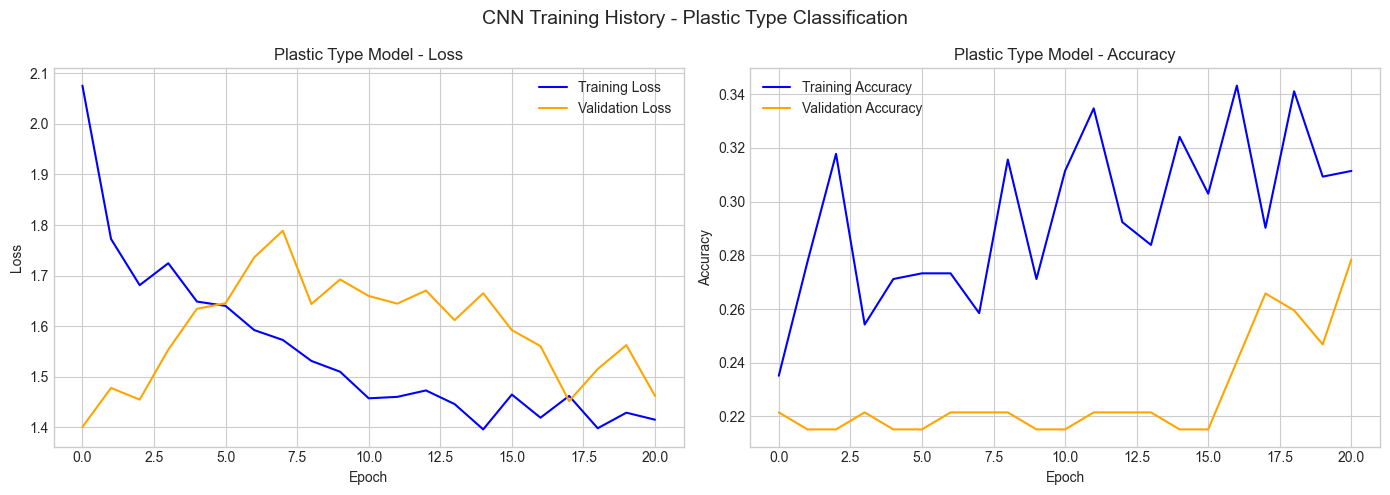

In [27]:
# Plot training history for plastic type model
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Loss plot
axes[0].plot(history_plastic.history['loss'], label='Training Loss', color='blue')
axes[0].plot(history_plastic.history['val_loss'], label='Validation Loss', color='orange')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Loss')
axes[0].set_title('Plastic Type Model - Loss')
axes[0].legend()
axes[0].grid(True)

# Accuracy plot
axes[1].plot(history_plastic.history['accuracy'], label='Training Accuracy', color='blue')
axes[1].plot(history_plastic.history['val_accuracy'], label='Validation Accuracy', color='orange')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Accuracy')
axes[1].set_title('Plastic Type Model - Accuracy')
axes[1].legend()
axes[1].grid(True)

plt.suptitle('CNN Training History - Plastic Type Classification', fontsize=14)
plt.tight_layout()
plt.savefig(project_root / 'reports' / 'figures' / 'cnn_plastic_training_history.png', dpi=150)
plt.show()

In [28]:
# Evaluate plastic type model on test set
y_plastic_pred_proba = cnn_plastic.predict(X_test_cnn)
y_plastic_pred = np.argmax(y_plastic_pred_proba, axis=1)

print("=" * 60)
print("PLASTIC TYPE CLASSIFICATION RESULTS")
print("=" * 60)

# Accuracy
accuracy_plastic = accuracy_score(y_plastic_test, y_plastic_pred)
print(f"\nTest Accuracy: {accuracy_plastic:.4f}")

# Classification report
print("\nClassification Report:")
print(classification_report(y_plastic_test, y_plastic_pred, target_names=PLASTIC_TYPES))

5/5 ━━━━━━━━━━━━━━━━━━━━ 2s 264ms/step
PLASTIC TYPE CLASSIFICATION RESULTS

Test Accuracy: 0.2278

Classification Report:
              precision    recall  f1-score   support

          PP       0.23      1.00      0.37        34
        LDPE       0.29      0.05      0.09        38
       LLDPE       0.00      0.00      0.00        38
        HDPE       0.00      0.00      0.00        48

    accuracy                           0.23       158
   macro avg       0.13      0.26      0.11       158
weighted avg       0.12      0.23      0.10       158



c:\Users\Mikey\anaconda3\envs\CMSE\Lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Users\Mikey\anaconda3\envs\CMSE\Lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Users\Mikey\anaconda3\envs\CMSE\Lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0]

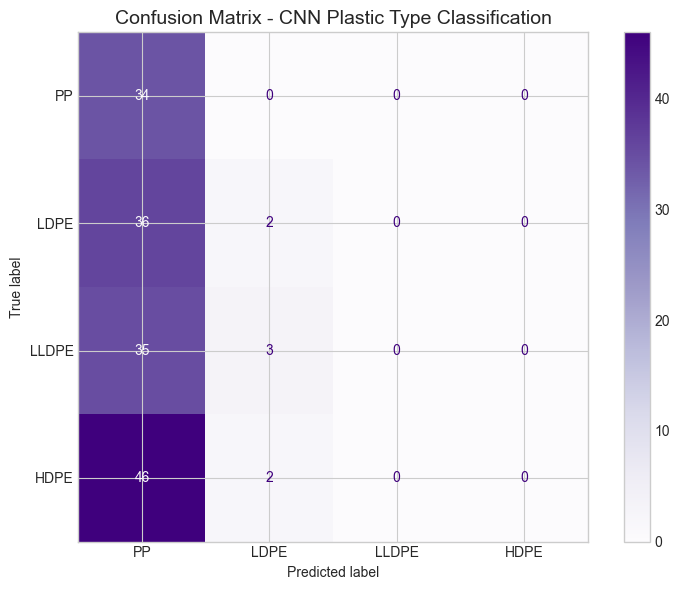

In [29]:
# Confusion matrix for plastic type
cm_plastic = confusion_matrix(y_plastic_test, y_plastic_pred)

fig, ax = plt.subplots(figsize=(8, 6))
disp = ConfusionMatrixDisplay(confusion_matrix=cm_plastic, display_labels=PLASTIC_TYPES)
disp.plot(ax=ax, cmap='Purples', colorbar=True)
ax.set_title('Confusion Matrix - CNN Plastic Type Classification', fontsize=14)
plt.tight_layout()
plt.savefig(project_root / 'reports' / 'figures' / 'cnn_plastic_confusion_matrix.png', dpi=150)
plt.show()

## 5. Train CNN for Contaminant Detection (Multi-Label)

In [30]:
# Reset callbacks for contaminant model
early_stopping_cont = EarlyStopping(
    monitor='val_loss',
    patience=20,
    restore_best_weights=True,
    verbose=1
)

reduce_lr_cont = ReduceLROnPlateau(
    monitor='val_loss',
    factor=0.5,
    patience=10,
    min_lr=1e-6,
    verbose=1
)

# Train contaminant detection model
print("=" * 60)
print("TRAINING CNN FOR CONTAMINANT DETECTION")
print("=" * 60)

history_contaminant = cnn_contaminant.fit(
    X_train_cnn, y_contaminant_train,
    validation_data=(X_val_cnn, y_contaminant_val),
    epochs=100,
    batch_size=16,
    callbacks=[early_stopping_cont, reduce_lr_cont],
    verbose=1
)

TRAINING CNN FOR CONTAMINANT DETECTION
Epoch 1/100
30/30 ━━━━━━━━━━━━━━━━━━━━ 48s 1s/step - accuracy: 0.2331 - loss: 0.8783 - val_accuracy: 0.3734 - val_loss: 0.6674 - learning_rate: 0.0010
Epoch 2/100
30/30 ━━━━━━━━━━━━━━━━━━━━ 43s 1s/step - accuracy: 0.2945 - loss: 0.7473 - val_accuracy: 0.3101 - val_loss: 0.6440 - learning_rate: 0.0010
Epoch 3/100
30/30 ━━━━━━━━━━━━━━━━━━━━ 46s 2s/step - accuracy: 0.2966 - loss: 0.7097 - val_accuracy: 0.2658 - val_loss: 0.6223 - learning_rate: 0.0010
Epoch 4/100
30/30 ━━━━━━━━━━━━━━━━━━━━ 44s 1s/step - accuracy: 0.3008 - loss: 0.6684 - val_accuracy: 0.2975 - val_loss: 0.6105 - learning_rate: 0.0010
Epoch 5/100
30/30 ━━━━━━━━━━━━━━━━━━━━ 44s 1s/step - accuracy: 0.3008 - loss: 0.6778 - val_accuracy: 0.3418 - val_loss: 0.5988 - learning_rate: 0.0010
Epoch 6/100
30/30 ━━━━━━━━━━━━━━━━━━━━ 48s 2s/step - accuracy: 0.3008 - loss: 0.6696 - val_accuracy: 0.3544 - val_loss: 0.6025 - learning_rate: 0.0010
Epoch 7/100
30/30 ━━━━━━━━━━━━━━━━━━━━ 52s 2s/step - ac

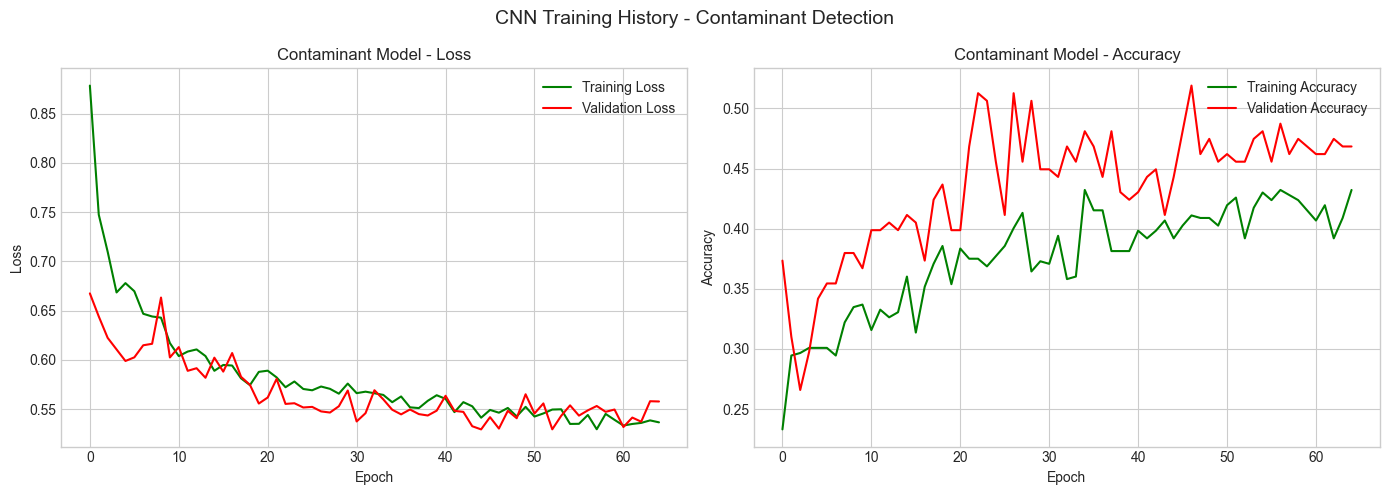

In [31]:
# Plot training history for contaminant model
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Loss plot
axes[0].plot(history_contaminant.history['loss'], label='Training Loss', color='green')
axes[0].plot(history_contaminant.history['val_loss'], label='Validation Loss', color='red')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Loss')
axes[0].set_title('Contaminant Model - Loss')
axes[0].legend()
axes[0].grid(True)

# Accuracy plot
axes[1].plot(history_contaminant.history['accuracy'], label='Training Accuracy', color='green')
axes[1].plot(history_contaminant.history['val_accuracy'], label='Validation Accuracy', color='red')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Accuracy')
axes[1].set_title('Contaminant Model - Accuracy')
axes[1].legend()
axes[1].grid(True)

plt.suptitle('CNN Training History - Contaminant Detection', fontsize=14)
plt.tight_layout()
plt.savefig(project_root / 'reports' / 'figures' / 'cnn_contaminant_training_history.png', dpi=150)
plt.show()

In [32]:
# Evaluate contaminant model on test set
y_contaminant_pred_proba = cnn_contaminant.predict(X_test_cnn)
y_contaminant_pred = (y_contaminant_pred_proba > 0.5).astype(int)

print("=" * 60)
print("CONTAMINANT DETECTION RESULTS (Multi-Label)")
print("=" * 60)

# Hamming loss
h_loss = hamming_loss(y_contaminant_test, y_contaminant_pred)
print(f"\nHamming Loss: {h_loss:.4f}")

# Exact match ratio (subset accuracy)
exact_match = accuracy_score(y_contaminant_test, y_contaminant_pred)
print(f"Exact Match Ratio (Subset Accuracy): {exact_match:.4f}")

# Per-label metrics
print("\nPer-Contaminant Performance:")
print("-" * 50)
for i, contaminant in enumerate(CONTAMINANTS):
    acc = accuracy_score(y_contaminant_test[:, i], y_contaminant_pred[:, i])
    f1 = f1_score(y_contaminant_test[:, i], y_contaminant_pred[:, i], zero_division=0)
    print(f"{contaminant:10s}: Accuracy = {acc:.4f}, F1-Score = {f1:.4f}")

5/5 ━━━━━━━━━━━━━━━━━━━━ 2s 399ms/step
CONTAMINANT DETECTION RESULTS (Multi-Label)

Hamming Loss: 0.2679
Exact Match Ratio (Subset Accuracy): 0.1582

Per-Contaminant Performance:
--------------------------------------------------
BSA       : Accuracy = 0.7532, F1-Score = 0.7692
Oil       : Accuracy = 0.6456, F1-Score = 0.6216
Starch    : Accuracy = 0.6709, F1-Score = 0.6486
CMC       : Accuracy = 0.7278, F1-Score = 0.6055
Guar      : Accuracy = 0.6456, F1-Score = 0.6364
Casein    : Accuracy = 0.9494, F1-Score = 0.0000


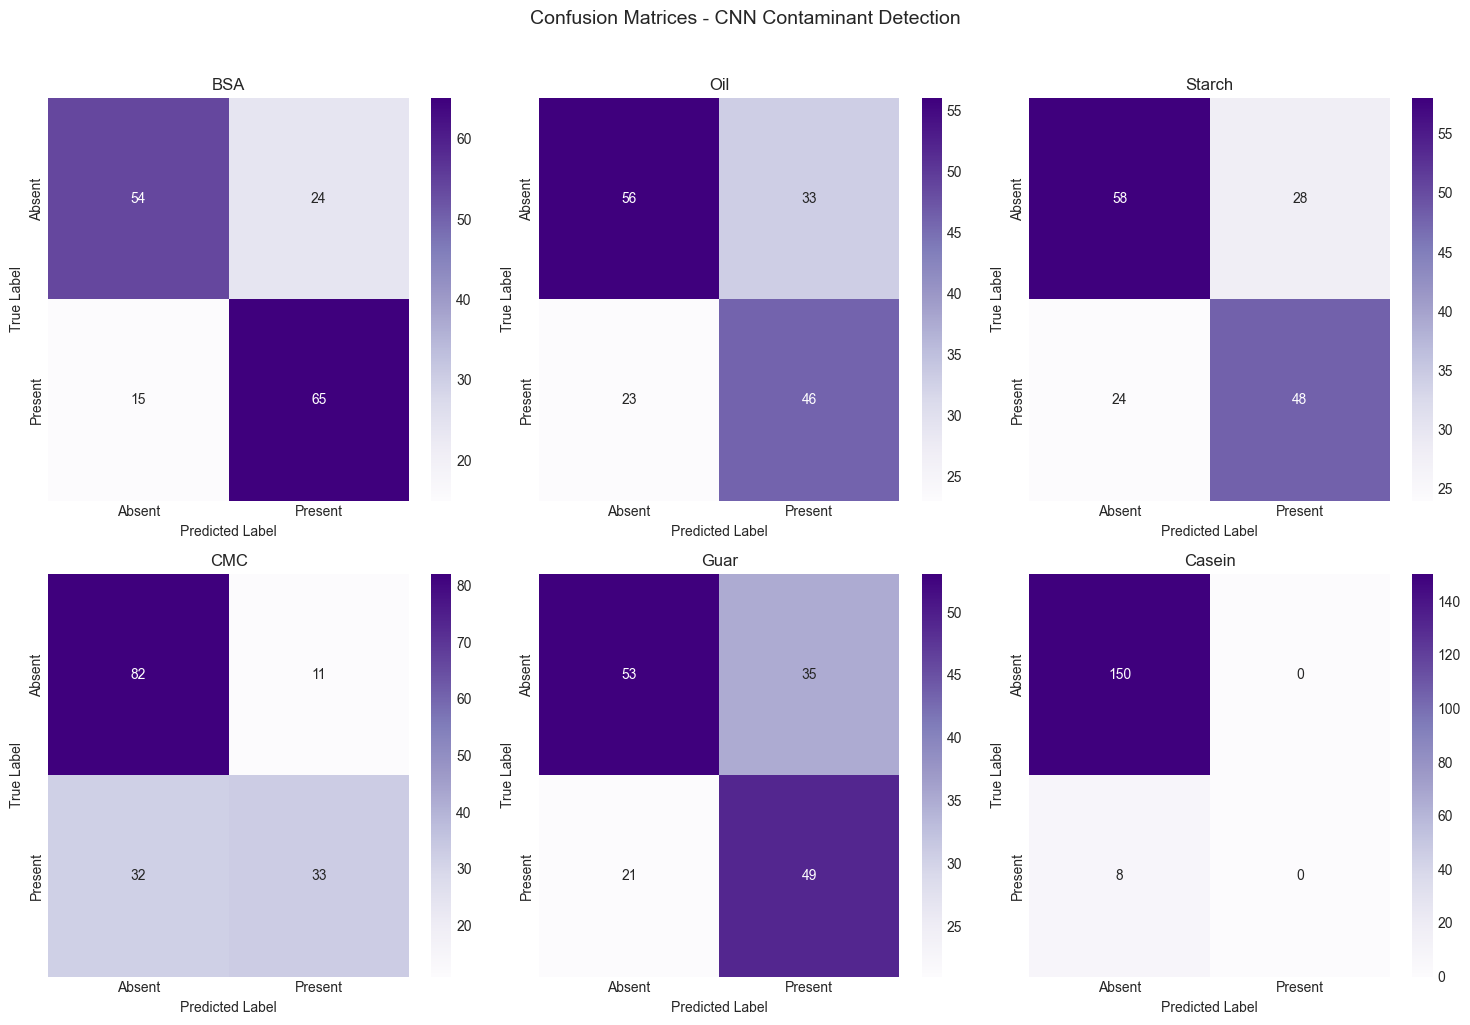

In [33]:
# Confusion matrices for each contaminant
fig, axes = plt.subplots(2, 3, figsize=(15, 10))
axes = axes.flatten()

for i, (ax, contaminant) in enumerate(zip(axes, CONTAMINANTS)):
    cm = confusion_matrix(y_contaminant_test[:, i], y_contaminant_pred[:, i])
    sns.heatmap(cm, annot=True, fmt='d', cmap='Purples', ax=ax,
                xticklabels=['Absent', 'Present'],
                yticklabels=['Absent', 'Present'])
    ax.set_title(f'{contaminant}', fontsize=12)
    ax.set_ylabel('True Label')
    ax.set_xlabel('Predicted Label')

plt.suptitle('Confusion Matrices - CNN Contaminant Detection', fontsize=14, y=1.02)
plt.tight_layout()
plt.savefig(project_root / 'reports' / 'figures' / 'cnn_contaminant_confusion_matrices.png', dpi=150)
plt.show()

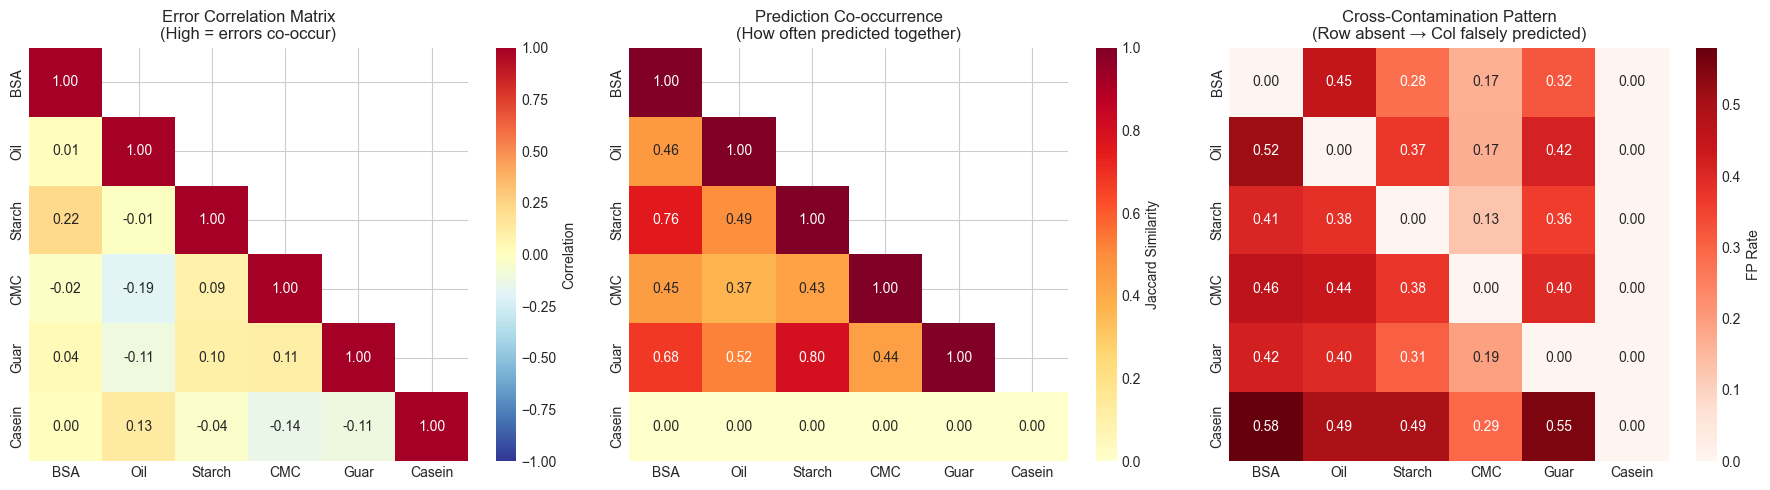


Most correlated error pairs (contaminants often misclassified together):
------------------------------------------------------------
  BSA <-> Starch: correlation = 0.224
  Oil <-> CMC: correlation = -0.186
  CMC <-> Casein: correlation = -0.141
  Oil <-> Casein: correlation = 0.131
  CMC <-> Guar: correlation = 0.112


In [34]:
# Analyze which contaminants are difficult to differentiate from each other
# Using pairwise error correlation and prediction similarity

# 1. Compute error vectors (1 = incorrect prediction, 0 = correct)
errors = (y_contaminant_test != y_contaminant_pred).astype(int)

# 2. Compute pairwise error correlation matrix
error_corr = np.corrcoef(errors.T)

# 3. Compute prediction similarity matrix (Jaccard similarity)
pred_similarity = np.zeros((len(CONTAMINANTS), len(CONTAMINANTS)))
for i in range(len(CONTAMINANTS)):
    for j in range(len(CONTAMINANTS)):
        both_present = np.sum((y_contaminant_pred[:, i] == 1) & (y_contaminant_pred[:, j] == 1))
        either_present = np.sum((y_contaminant_pred[:, i] == 1) | (y_contaminant_pred[:, j] == 1))
        pred_similarity[i, j] = both_present / either_present if either_present > 0 else 0

# 4. Create visualization
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Plot 1: Error correlation matrix
mask1 = np.triu(np.ones_like(error_corr, dtype=bool), k=1)
sns.heatmap(error_corr, annot=True, fmt='.2f', cmap='RdYlBu_r', 
            xticklabels=CONTAMINANTS, yticklabels=CONTAMINANTS,
            ax=axes[0], vmin=-1, vmax=1, mask=mask1,
            cbar_kws={'label': 'Correlation'})
axes[0].set_title('Error Correlation Matrix\n(High = errors co-occur)', fontsize=12)

# Plot 2: Prediction similarity (Jaccard)
mask2 = np.triu(np.ones_like(pred_similarity, dtype=bool), k=1)
sns.heatmap(pred_similarity, annot=True, fmt='.2f', cmap='YlOrRd',
            xticklabels=CONTAMINANTS, yticklabels=CONTAMINANTS,
            ax=axes[1], vmin=0, vmax=1, mask=mask2,
            cbar_kws={'label': 'Jaccard Similarity'})
axes[1].set_title('Prediction Co-occurrence\n(How often predicted together)', fontsize=12)

# Plot 3: Cross-contamination pattern
fp_when_absent = np.zeros((len(CONTAMINANTS), len(CONTAMINANTS)))
for i in range(len(CONTAMINANTS)):
    for j in range(len(CONTAMINANTS)):
        if i != j:
            i_absent = y_contaminant_test[:, i] == 0
            if np.sum(i_absent) > 0:
                fp_when_absent[i, j] = np.mean(y_contaminant_pred[i_absent, j])

sns.heatmap(fp_when_absent, annot=True, fmt='.2f', cmap='Reds',
            xticklabels=CONTAMINANTS, yticklabels=CONTAMINANTS,
            ax=axes[2], vmin=0,
            cbar_kws={'label': 'FP Rate'})
axes[2].set_title('Cross-Contamination Pattern\n(Row absent → Col falsely predicted)', fontsize=12)

plt.tight_layout()
plt.savefig(project_root / 'reports' / 'figures' / 'cnn_contaminant_confusion_analysis.png', dpi=150)
plt.show()

# Print summary of most confused pairs
print("\nMost correlated error pairs (contaminants often misclassified together):")
print("-" * 60)
error_pairs = []
for i in range(len(CONTAMINANTS)):
    for j in range(i+1, len(CONTAMINANTS)):
        if not np.isnan(error_corr[i, j]):
            error_pairs.append((CONTAMINANTS[i], CONTAMINANTS[j], error_corr[i, j]))

error_pairs.sort(key=lambda x: abs(x[2]), reverse=True)
for c1, c2, corr in error_pairs[:5]:
    print(f"  {c1} <-> {c2}: correlation = {corr:.3f}")

## 6. Combined Multi-Output CNN Model

In [35]:
def build_combined_cnn_model(input_shape, num_plastic_classes, num_contaminant_labels):
    """
    Build a multi-output CNN model with shared feature extraction
    and separate heads for plastic type and contaminant detection.
    """
    # Input layer
    inputs = Input(shape=input_shape)
    
    # Shared feature extraction layers
    x = Conv1D(32, kernel_size=11, activation='relu', padding='same')(inputs)
    x = BatchNormalization()(x)
    x = MaxPooling1D(pool_size=2)(x)
    x = Dropout(0.2)(x)
    
    x = Conv1D(64, kernel_size=7, activation='relu', padding='same')(x)
    x = BatchNormalization()(x)
    x = MaxPooling1D(pool_size=2)(x)
    x = Dropout(0.2)(x)
    
    x = Conv1D(128, kernel_size=5, activation='relu', padding='same')(x)
    x = BatchNormalization()(x)
    x = MaxPooling1D(pool_size=2)(x)
    x = Dropout(0.3)(x)
    
    x = Conv1D(256, kernel_size=3, activation='relu', padding='same')(x)
    x = BatchNormalization()(x)
    shared_features = GlobalAveragePooling1D()(x)
    shared_features = Dropout(0.4)(shared_features)
    
    # Plastic type classification head
    plastic_x = Dense(64, activation='relu')(shared_features)
    plastic_x = Dropout(0.3)(plastic_x)
    plastic_output = Dense(num_plastic_classes, activation='softmax', name='plastic_output')(plastic_x)
    
    # Contaminant detection head
    contaminant_x = Dense(64, activation='relu')(shared_features)
    contaminant_x = Dropout(0.3)(contaminant_x)
    contaminant_output = Dense(num_contaminant_labels, activation='sigmoid', name='contaminant_output')(contaminant_x)
    
    # Create model
    model = Model(inputs=inputs, outputs=[plastic_output, contaminant_output])
    
    model.compile(
        optimizer=Adam(learning_rate=0.001),
        loss={
            'plastic_output': 'categorical_crossentropy',
            'contaminant_output': 'binary_crossentropy'
        },
        loss_weights={'plastic_output': 1.0, 'contaminant_output': 1.0},
        metrics={'plastic_output': 'accuracy', 'contaminant_output': 'accuracy'}
    )
    
    return model

# Build combined model
cnn_combined = build_combined_cnn_model(input_shape, num_plastic_classes, num_contaminant_labels)
cnn_combined.summary()

Model: "functional_4"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_4       │ (None, 7469, 1)   │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d_16 (Conv1D)  │ (None, 7469, 32)  │        384 │ input_layer_4[0]… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 7469, 32)  │        128 │ conv1d_16[0][0]   │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling1d_12    │ (None, 3734, 32)  │          0 │ batch_normalizat… │
│ (MaxPooling1D)      │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_24          │ (None, 3734, 32)  │          0 │ max_pooling1d_12… │
│ (Dropout)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d_17 (Conv1D)  │ (None, 3734, 64)  │     14,400 │ dropout_24[0][0]  │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 3734, 64)  │        256 │ conv1d_17[0][0]   │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling1d_13    │ (None, 1867, 64)  │          0 │ batch_normalizat… │
│ (MaxPooling1D)      │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_25          │ (None, 1867, 64)  │          0 │ max_pooling1d_13… │
│ (Dropout)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d_18 (Conv1D)  │ (None, 1867, 128) │     41,088 │ dropout_25[0][0]  │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 1867, 128) │        512 │ conv1d_18[0][0]   │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling1d_14    │ (None, 933, 128)  │          0 │ batch_normalizat… │
│ (MaxPooling1D)      │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_26          │ (None, 933, 128)  │          0 │ max_pooling1d_14… │
│ (Dropout)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d_19 (Conv1D)  │ (None, 933, 256)  │     98,560 │ dropout_26[0][0]  │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 933, 256)  │      1,024 │ conv1d_19[0][0]   │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ global_average_poo… │ (None, 256)       │          0 │ batch_normalizat… │
│ (GlobalAveragePool… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_27          │ (None, 256)       │          0 │ global_average_p… │
│ (Dropout)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_12 (Dense)    │ (None, 64)        │     16,448 │ dropout_27[0][0]  │
├─────────────────────┼───────────────────┼────────────┼─────────────────

 Total params: 189,898 (741.79 KB)

 Trainable params: 188,938 (738.04 KB)

 Non-trainable params: 960 (3.75 KB)

In [36]:
# Train combined model
early_stopping_combined = EarlyStopping(
    monitor='val_loss',
    patience=20,
    restore_best_weights=True,
    verbose=1
)

reduce_lr_combined = ReduceLROnPlateau(
    monitor='val_loss',
    factor=0.5,
    patience=10,
    min_lr=1e-6,
    verbose=1
)

print("=" * 60)
print("TRAINING COMBINED MULTI-OUTPUT CNN MODEL")
print("=" * 60)

history_combined = cnn_combined.fit(
    X_train_cnn,
    {'plastic_output': y_plastic_onehot_train, 'contaminant_output': y_contaminant_train},
    validation_data=(
        X_val_cnn,
        {'plastic_output': y_plastic_onehot_val, 'contaminant_output': y_contaminant_val}
    ),
    epochs=100,
    batch_size=16,
    callbacks=[early_stopping_combined, reduce_lr_combined],
    verbose=1
)

TRAINING COMBINED MULTI-OUTPUT CNN MODEL
Epoch 1/100
30/30 ━━━━━━━━━━━━━━━━━━━━ 27s 687ms/step - contaminant_output_accuracy: 0.2691 - contaminant_output_loss: 0.6766 - loss: 2.2234 - plastic_output_accuracy: 0.2521 - plastic_output_loss: 1.5447 - val_contaminant_output_accuracy: 0.3101 - val_contaminant_output_loss: 0.6534 - val_loss: 2.0533 - val_plastic_output_accuracy: 0.3101 - val_plastic_output_loss: 1.4003 - learning_rate: 0.0010
Epoch 2/100
30/30 ━━━━━━━━━━━━━━━━━━━━ 21s 694ms/step - contaminant_output_accuracy: 0.3242 - contaminant_output_loss: 0.6525 - loss: 2.1185 - plastic_output_accuracy: 0.3072 - plastic_output_loss: 1.4639 - val_contaminant_output_accuracy: 0.2975 - val_contaminant_output_loss: 0.6140 - val_loss: 2.0636 - val_plastic_output_accuracy: 0.2152 - val_plastic_output_loss: 1.4501 - learning_rate: 0.0010
Epoch 3/100
30/30 ━━━━━━━━━━━━━━━━━━━━ 22s 743ms/step - contaminant_output_accuracy: 0.2669 - contaminant_output_loss: 0.6304 - loss: 2.1021 - plastic_output_a

In [37]:
# Evaluate combined model
y_combined_pred = cnn_combined.predict(X_test_cnn)
y_plastic_combined_pred = np.argmax(y_combined_pred[0], axis=1)
y_contaminant_combined_pred = (y_combined_pred[1] > 0.5).astype(int)

print("=" * 60)
print("COMBINED MODEL RESULTS")
print("=" * 60)

# Plastic type accuracy
plastic_acc_combined = accuracy_score(y_plastic_test, y_plastic_combined_pred)
print(f"\nPlastic Type Accuracy: {plastic_acc_combined:.4f}")

# Contaminant metrics
contaminant_h_loss = hamming_loss(y_contaminant_test, y_contaminant_combined_pred)
print(f"Contaminant Hamming Loss: {contaminant_h_loss:.4f}")

# Overall exact match (all outputs correct)
plastic_match = (y_plastic_test == y_plastic_combined_pred)
contaminant_match = np.all(y_contaminant_test == y_contaminant_combined_pred, axis=1)
overall_exact_match = np.mean(plastic_match & contaminant_match)
print(f"Overall Exact Match Ratio: {overall_exact_match:.4f}")

4/5 ━━━━━━━━━━━━━━━━━━━━ 0s 301ms/stepWARNING:tensorflow:5 out of the last 11 calls to <function TensorFlowTrainer.make_predict_function.<locals>.one_step_on_data_distributed at 0x0000028164A7E160> triggered tf.function retracing. Tracing is expensive and the excessive number of tracings could be due to (1) creating @tf.function repeatedly in a loop, (2) passing tensors with different shapes, (3) passing Python objects instead of tensors. For (1), please define your @tf.function outside of the loop. For (2), @tf.function has reduce_retracing=True option that can avoid unnecessary retracing. For (3), please refer to https://www.tensorflow.org/guide/function#controlling_retracing and https://www.tensorflow.org/api_docs/python/tf/function for  more details.
5/5 ━━━━━━━━━━━━━━━━━━━━ 2s 359ms/step
COMBINED MODEL RESULTS

Plastic Type Accuracy: 0.2848
Contaminant Hamming Loss: 0.3850
Overall Exact Match Ratio: 0.0127


## 7. Save Models and Results

In [38]:
import joblib
from datetime import datetime

# Create output directories
models_dir = Path('.').resolve()
reports_dir = project_root / 'reports' / 'text_reports'
figures_dir = project_root / 'reports' / 'figures'

models_dir.mkdir(parents=True, exist_ok=True)
reports_dir.mkdir(parents=True, exist_ok=True)
figures_dir.mkdir(parents=True, exist_ok=True)

# Save models
timestamp = datetime.now().strftime('%Y%m%d_%H%M%S')

cnn_plastic.save(models_dir / f'cnn_plastic_model_{timestamp}.keras')
cnn_contaminant.save(models_dir / f'cnn_contaminant_model_{timestamp}.keras')
cnn_combined.save(models_dir / f'cnn_combined_model_{timestamp}.keras')
joblib.dump(scaler, models_dir / f'cnn_scaler_{timestamp}.joblib')

print(f"Models saved to: {models_dir}")

Models saved to: C:\Users\Mikey\Desktop\PhD writings\AI washing\AI-edited program file\src\models\CNN


In [39]:
# Generate and save text report
report = f"""
================================================================================
CNN MODEL EVALUATION REPORT
================================================================================
Date: {datetime.now().strftime('%Y-%m-%d %H:%M:%S')}
Data: IR Spectral Data
Training samples: {X_train.shape[0]}
Validation samples: {X_val.shape[0]}
Test samples: {X_test.shape[0]}
Features: {X_train.shape[1]} (wavenumber points)

--------------------------------------------------------------------------------
1. PLASTIC TYPE CLASSIFICATION (Multi-class)
--------------------------------------------------------------------------------
Classes: {PLASTIC_TYPES}
Test Accuracy: {accuracy_plastic:.4f}

{classification_report(y_plastic_test, y_plastic_pred, target_names=PLASTIC_TYPES)}

--------------------------------------------------------------------------------
2. CONTAMINANT DETECTION (Multi-label)
--------------------------------------------------------------------------------
Contaminants: {CONTAMINANTS}
Hamming Loss: {h_loss:.4f}
Exact Match Ratio: {exact_match:.4f}

Per-contaminant Performance:
"""

for i, contaminant in enumerate(CONTAMINANTS):
    acc = accuracy_score(y_contaminant_test[:, i], y_contaminant_pred[:, i])
    f1 = f1_score(y_contaminant_test[:, i], y_contaminant_pred[:, i], zero_division=0)
    report += f"  {contaminant}: Accuracy={acc:.4f}, F1-Score={f1:.4f}\n"

report += f"""
--------------------------------------------------------------------------------
3. COMBINED MODEL
--------------------------------------------------------------------------------
Plastic Type Accuracy: {plastic_acc_combined:.4f}
Contaminant Hamming Loss: {contaminant_h_loss:.4f}
Overall Exact Match Ratio: {overall_exact_match:.4f}

================================================================================
"""

# Save report
report_path = reports_dir / f'cnn_evaluation_report_{timestamp}.txt'
with open(report_path, 'w') as f:
    f.write(report)

print(report)
print(f"\nReport saved to: {report_path}")


CNN MODEL EVALUATION REPORT
Date: 2026-01-06 21:06:29
Data: IR Spectral Data
Training samples: 472
Validation samples: 158
Test samples: 158
Features: 7469 (wavenumber points)

--------------------------------------------------------------------------------
1. PLASTIC TYPE CLASSIFICATION (Multi-class)
--------------------------------------------------------------------------------
Classes: ['PP', 'LDPE', 'LLDPE', 'HDPE']
Test Accuracy: 0.2278

              precision    recall  f1-score   support

          PP       0.23      1.00      0.37        34
        LDPE       0.29      0.05      0.09        38
       LLDPE       0.00      0.00      0.00        38
        HDPE       0.00      0.00      0.00        48

    accuracy                           0.23       158
   macro avg       0.13      0.26      0.11       158
weighted avg       0.12      0.23      0.10       158


--------------------------------------------------------------------------------
2. CONTAMINANT DETECTION (Multi-la

c:\Users\Mikey\anaconda3\envs\CMSE\Lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Users\Mikey\anaconda3\envs\CMSE\Lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Users\Mikey\anaconda3\envs\CMSE\Lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0]

## 8. Feature Importance Analysis (Gradient-Based)

Computing gradient-based feature importance for plastic type model...


C:\Users\Mikey\AppData\Local\Temp\ipykernel_19248\244136055.py:47: UserWarning: Glyph 8315 (\N{SUPERSCRIPT MINUS}) missing from font(s) Arial.
  plt.tight_layout()
C:\Users\Mikey\AppData\Local\Temp\ipykernel_19248\244136055.py:48: UserWarning: Glyph 8315 (\N{SUPERSCRIPT MINUS}) missing from font(s) Arial.
  plt.savefig(project_root / 'reports' / 'figures' / 'cnn_feature_importance_plastic.png', dpi=150)
c:\Users\Mikey\anaconda3\envs\CMSE\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 8315 (\N{SUPERSCRIPT MINUS}) missing from font(s) Arial.
  fig.canvas.print_figure(bytes_io, **kw)


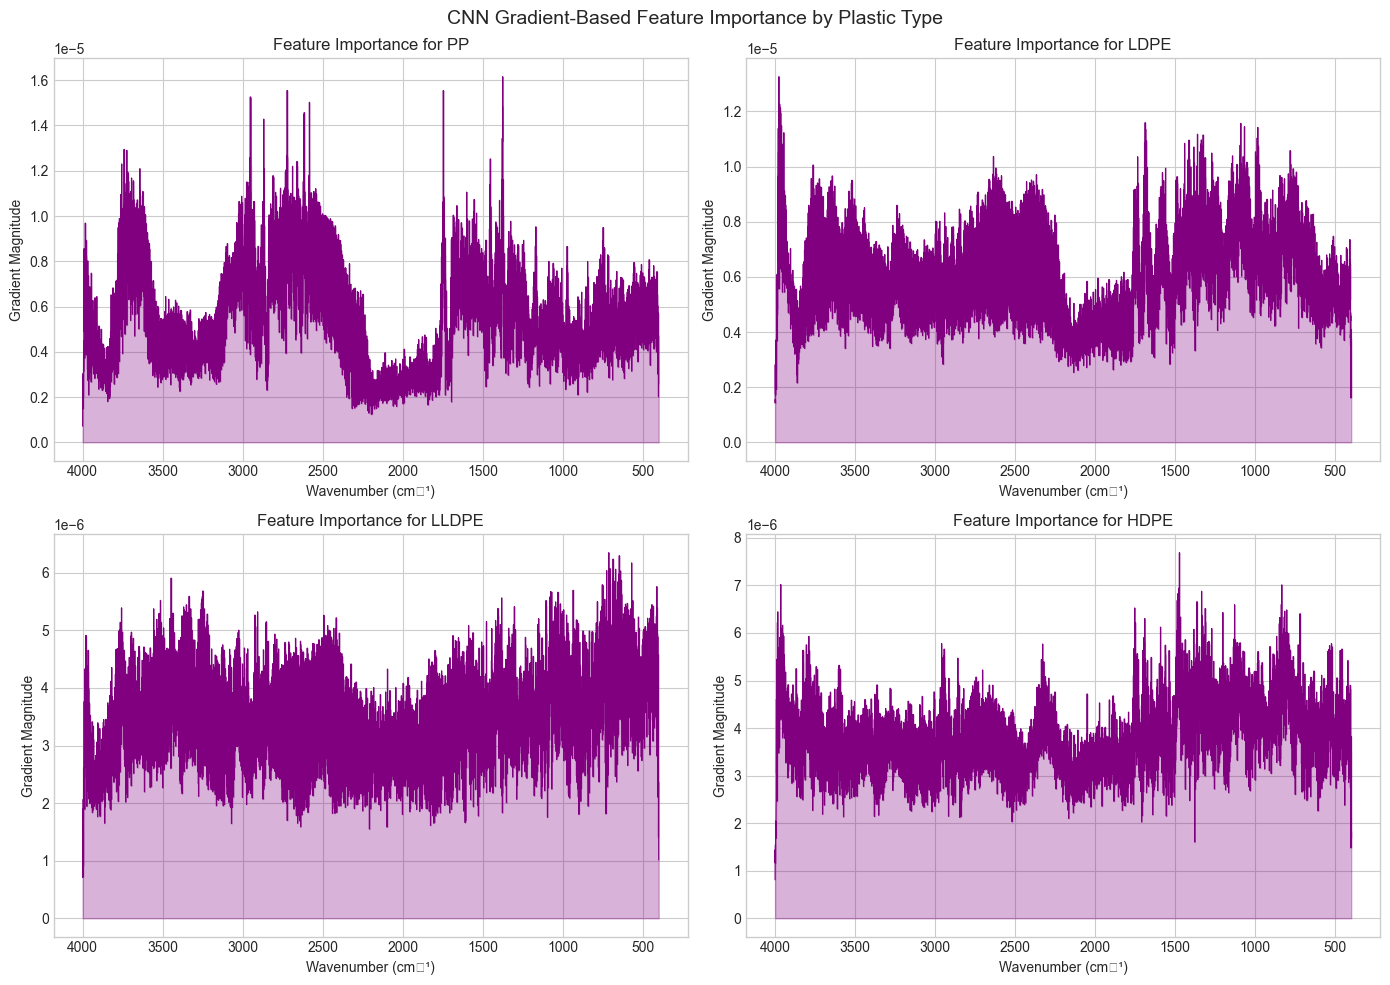

In [40]:
# Compute gradient-based feature importance using integrated gradients approximation
# This shows which wavenumbers the CNN focuses on for classification

def compute_gradient_importance(model, X_sample, class_idx=None):
    """
    Compute gradient-based feature importance for a sample.
    """
    X_tensor = tf.convert_to_tensor(X_sample, dtype=tf.float32)
    
    with tf.GradientTape() as tape:
        tape.watch(X_tensor)
        predictions = model(X_tensor)
        if class_idx is not None:
            target = predictions[:, class_idx]
        else:
            target = tf.reduce_max(predictions, axis=1)
    
    gradients = tape.gradient(target, X_tensor)
    return gradients.numpy()

# Compute average gradient importance for each plastic type
print("Computing gradient-based feature importance for plastic type model...")

fig, axes = plt.subplots(2, 2, figsize=(14, 10))
axes = axes.flatten()

for class_idx, (ax, plastic) in enumerate(zip(axes, PLASTIC_TYPES)):
    # Get samples of this class
    class_mask = y_plastic_test == class_idx
    X_class = X_test_cnn[class_mask]
    
    if len(X_class) > 0:
        # Compute gradients for all samples of this class
        gradients = compute_gradient_importance(cnn_plastic, X_class, class_idx)
        
        # Average absolute gradients
        avg_importance = np.mean(np.abs(gradients), axis=0).flatten()
        
        ax.plot(wavenumbers, avg_importance, linewidth=0.8, color='purple')
        ax.fill_between(wavenumbers, avg_importance, alpha=0.3, color='purple')
        ax.set_xlabel('Wavenumber (cm⁻¹)', fontsize=10)
        ax.set_ylabel('Gradient Magnitude', fontsize=10)
        ax.set_title(f'Feature Importance for {plastic}', fontsize=12)
        ax.invert_xaxis()

plt.suptitle('CNN Gradient-Based Feature Importance by Plastic Type', fontsize=14)
plt.tight_layout()
plt.savefig(project_root / 'reports' / 'figures' / 'cnn_feature_importance_plastic.png', dpi=150)
plt.show()

In [41]:
# Top 20 most important features for plastic type classification
print("\n" + "=" * 80)
print("TOP 20 MOST IMPORTANT FEATURES BY PLASTIC TYPE (CNN Gradients)")
print("=" * 80)

for class_idx, plastic in enumerate(PLASTIC_TYPES):
    class_mask = y_plastic_test == class_idx
    X_class = X_test_cnn[class_mask]
    
    if len(X_class) > 0:
        gradients = compute_gradient_importance(cnn_plastic, X_class, class_idx)
        avg_importance = np.mean(np.abs(gradients), axis=0).flatten()
        
        # Get top 20 indices
        top_indices = np.argsort(avg_importance)[::-1][:20]
        
        top_features_df = pd.DataFrame({
            'Rank': range(1, 21),
            'Wavenumber (cm⁻¹)': [f"{wavenumbers[idx]:.1f}" for idx in top_indices],
            'Gradient Magnitude': [f"{avg_importance[idx]:.6f}" for idx in top_indices]
        })
        
        print(f"\n{plastic}:")
        print("-" * 50)
        print(top_features_df.to_string(index=False))


TOP 20 MOST IMPORTANT FEATURES BY PLASTIC TYPE (CNN Gradients)

PP:
--------------------------------------------------
 Rank Wavenumber (cm⁻¹) Gradient Magnitude
    1            1374.5           0.000016
    2            2721.6           0.000016
    3            1745.8           0.000016
    4            2952.0           0.000015
    5            2949.2           0.000015
    6            2582.7           0.000015
    7            1375.5           0.000015
    8            2615.0           0.000015
    9            2617.5           0.000014
   10            2868.2           0.000014
   11            2721.1           0.000014
   12            1377.4           0.000013
   13            2720.6           0.000013
   14            1375.0           0.000013
   15            3740.8           0.000013
   16            3723.9           0.000013
   17            2723.5           0.000013
   18            2719.2           0.000013
   19            2954.0           0.000013
   20            145


Visualizing first layer CNN filters...
First conv layer filter shape: (11, 1, 32)
  - Kernel size: 11
  - Input channels: 1
  - Number of filters: 32


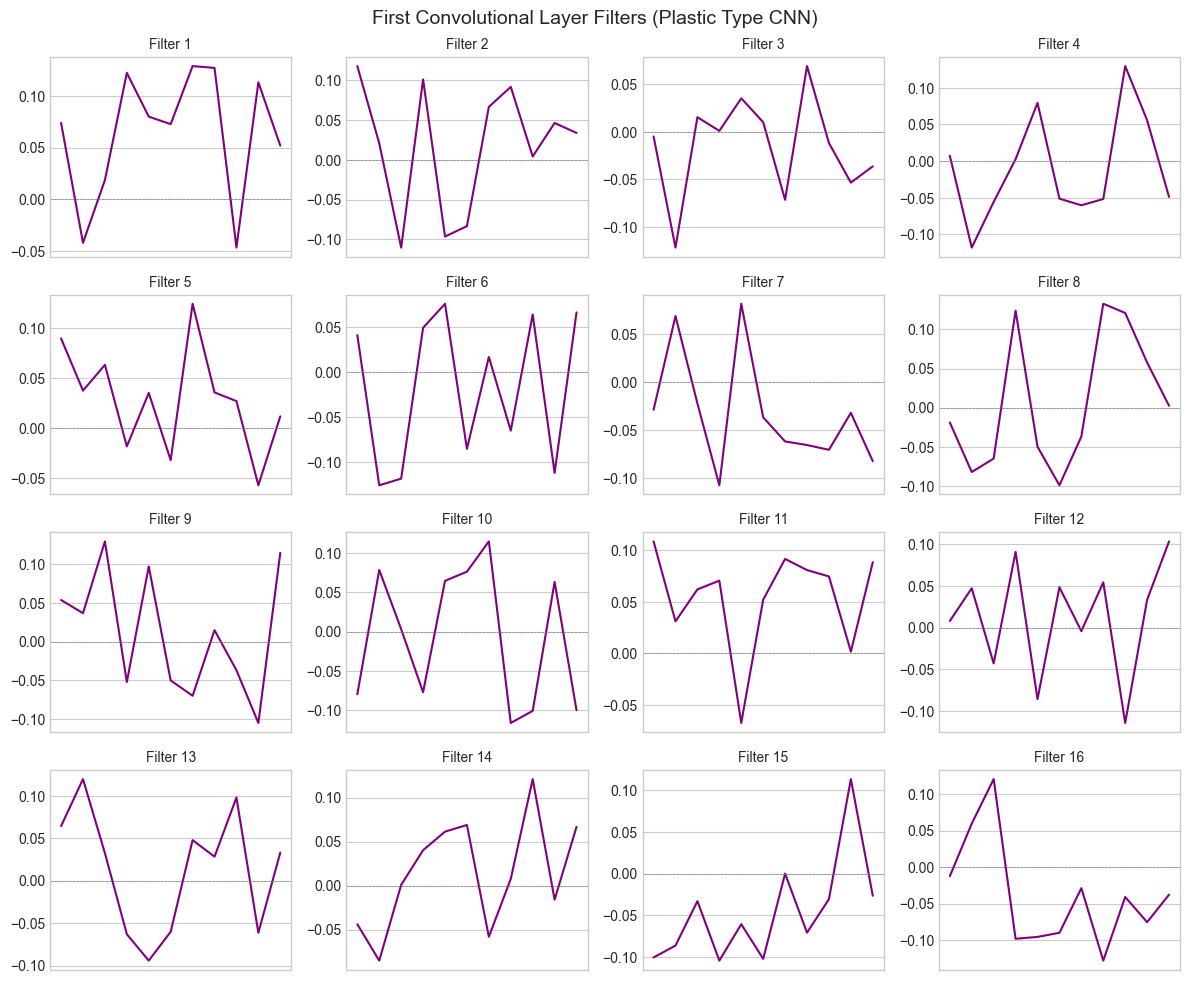

In [42]:
# Visualize CNN filters from first convolutional layer
print("\nVisualizing first layer CNN filters...")

# Get weights from first conv layer
first_conv_layer = cnn_plastic.layers[0]
filters, biases = first_conv_layer.get_weights()

print(f"First conv layer filter shape: {filters.shape}")
print(f"  - Kernel size: {filters.shape[0]}")
print(f"  - Input channels: {filters.shape[1]}")
print(f"  - Number of filters: {filters.shape[2]}")

# Plot first 16 filters
n_filters_to_plot = min(16, filters.shape[2])
fig, axes = plt.subplots(4, 4, figsize=(12, 10))
axes = axes.flatten()

for i in range(n_filters_to_plot):
    ax = axes[i]
    filter_weights = filters[:, 0, i]
    ax.plot(filter_weights, linewidth=1.5, color='purple')
    ax.set_title(f'Filter {i+1}', fontsize=10)
    ax.axhline(y=0, color='gray', linestyle='--', linewidth=0.5)
    ax.set_xticks([])

plt.suptitle('First Convolutional Layer Filters (Plastic Type CNN)', fontsize=14)
plt.tight_layout()
plt.savefig(project_root / 'reports' / 'figures' / 'cnn_first_layer_filters.png', dpi=150)
plt.show()

In [43]:
print("CNN model training and evaluation complete!")
print(f"\nSummary:")
print(f"  - Plastic Type Classification Accuracy: {accuracy_plastic:.2%}")
print(f"  - Contaminant Detection Hamming Loss: {h_loss:.4f}")
print(f"  - Combined Model Exact Match: {overall_exact_match:.2%}")
print(f"  - Models saved to: {models_dir}")
print(f"  - Reports saved to: {reports_dir}")
print(f"  - Figures saved to: {figures_dir}")

CNN model training and evaluation complete!

Summary:
  - Plastic Type Classification Accuracy: 22.78%
  - Contaminant Detection Hamming Loss: 0.2679
  - Combined Model Exact Match: 1.27%
  - Models saved to: C:\Users\Mikey\Desktop\PhD writings\AI washing\AI-edited program file\src\models\CNN
  - Reports saved to: C:\Users\Mikey\Desktop\PhD writings\AI washing\AI-edited program file\reports\text_reports
  - Figures saved to: C:\Users\Mikey\Desktop\PhD writings\AI washing\AI-edited program file\reports\figures
